In [1]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import healpy as hp
import json
import pickle

import sys
sys.path.append("..")
from utils.validation import roc_finite_sample_band
from utils.multi_corner import multi_corner

import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc_file("../../nptf-test/production/matplotlibrc")

# svi/hmc-pois-coverage

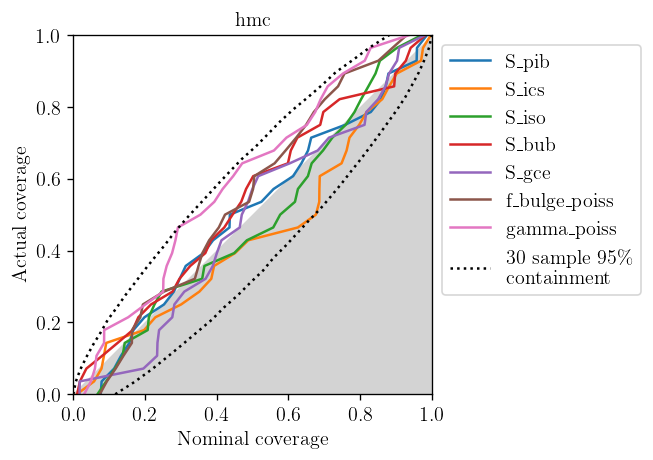

In [4]:
plot_name = 'hmc'
z = json.load(open(f'../outputs/fit/{plot_name}_Dpois_Mpois/p_nominal_actual_dict.json', 'r'))

labels = [
    'S_pib', 'S_ics', 'S_iso', 'S_bub', 'S_gce',
    'f_bulge_poiss', 'gamma_poiss',
]
probs = [z[k] for k in labels]
ls_s = ['-'] * 10 + [':'] * 10

fig, ax = plt.subplots()

ax.fill_between([0,1], [0,1], color='lightgray')
if labels is None:
    labels = [None for _ in probs]
for prob, label, ls in zip(probs, labels, ls_s):
    ax.plot(prob[0], prob[1], label=label, ls=ls)

n_run = 30
invcdf_lower, invcdf_upper = roc_finite_sample_band(n_run)
ax.plot(invcdf_upper, np.linspace(0, 1, n_run), 'k:', label=f'{n_run} sample 95\% \ncontainment')
ax.plot(invcdf_lower, np.linspace(0, 1, n_run), 'k:')

ax.set(aspect=1, xlim=(0, 1), ylim=(0, 1))
ax.set(xlabel='Nominal coverage', ylabel='Actual coverage', title=plot_name)

fig.legend(bbox_to_anchor=(1, 1), loc='upper left', bbox_transform=ax.transAxes)
fig.tight_layout()
fig.savefig(f'plots/{plot_name}-pois-coverage.pdf')

# hmc-svi-pois-post

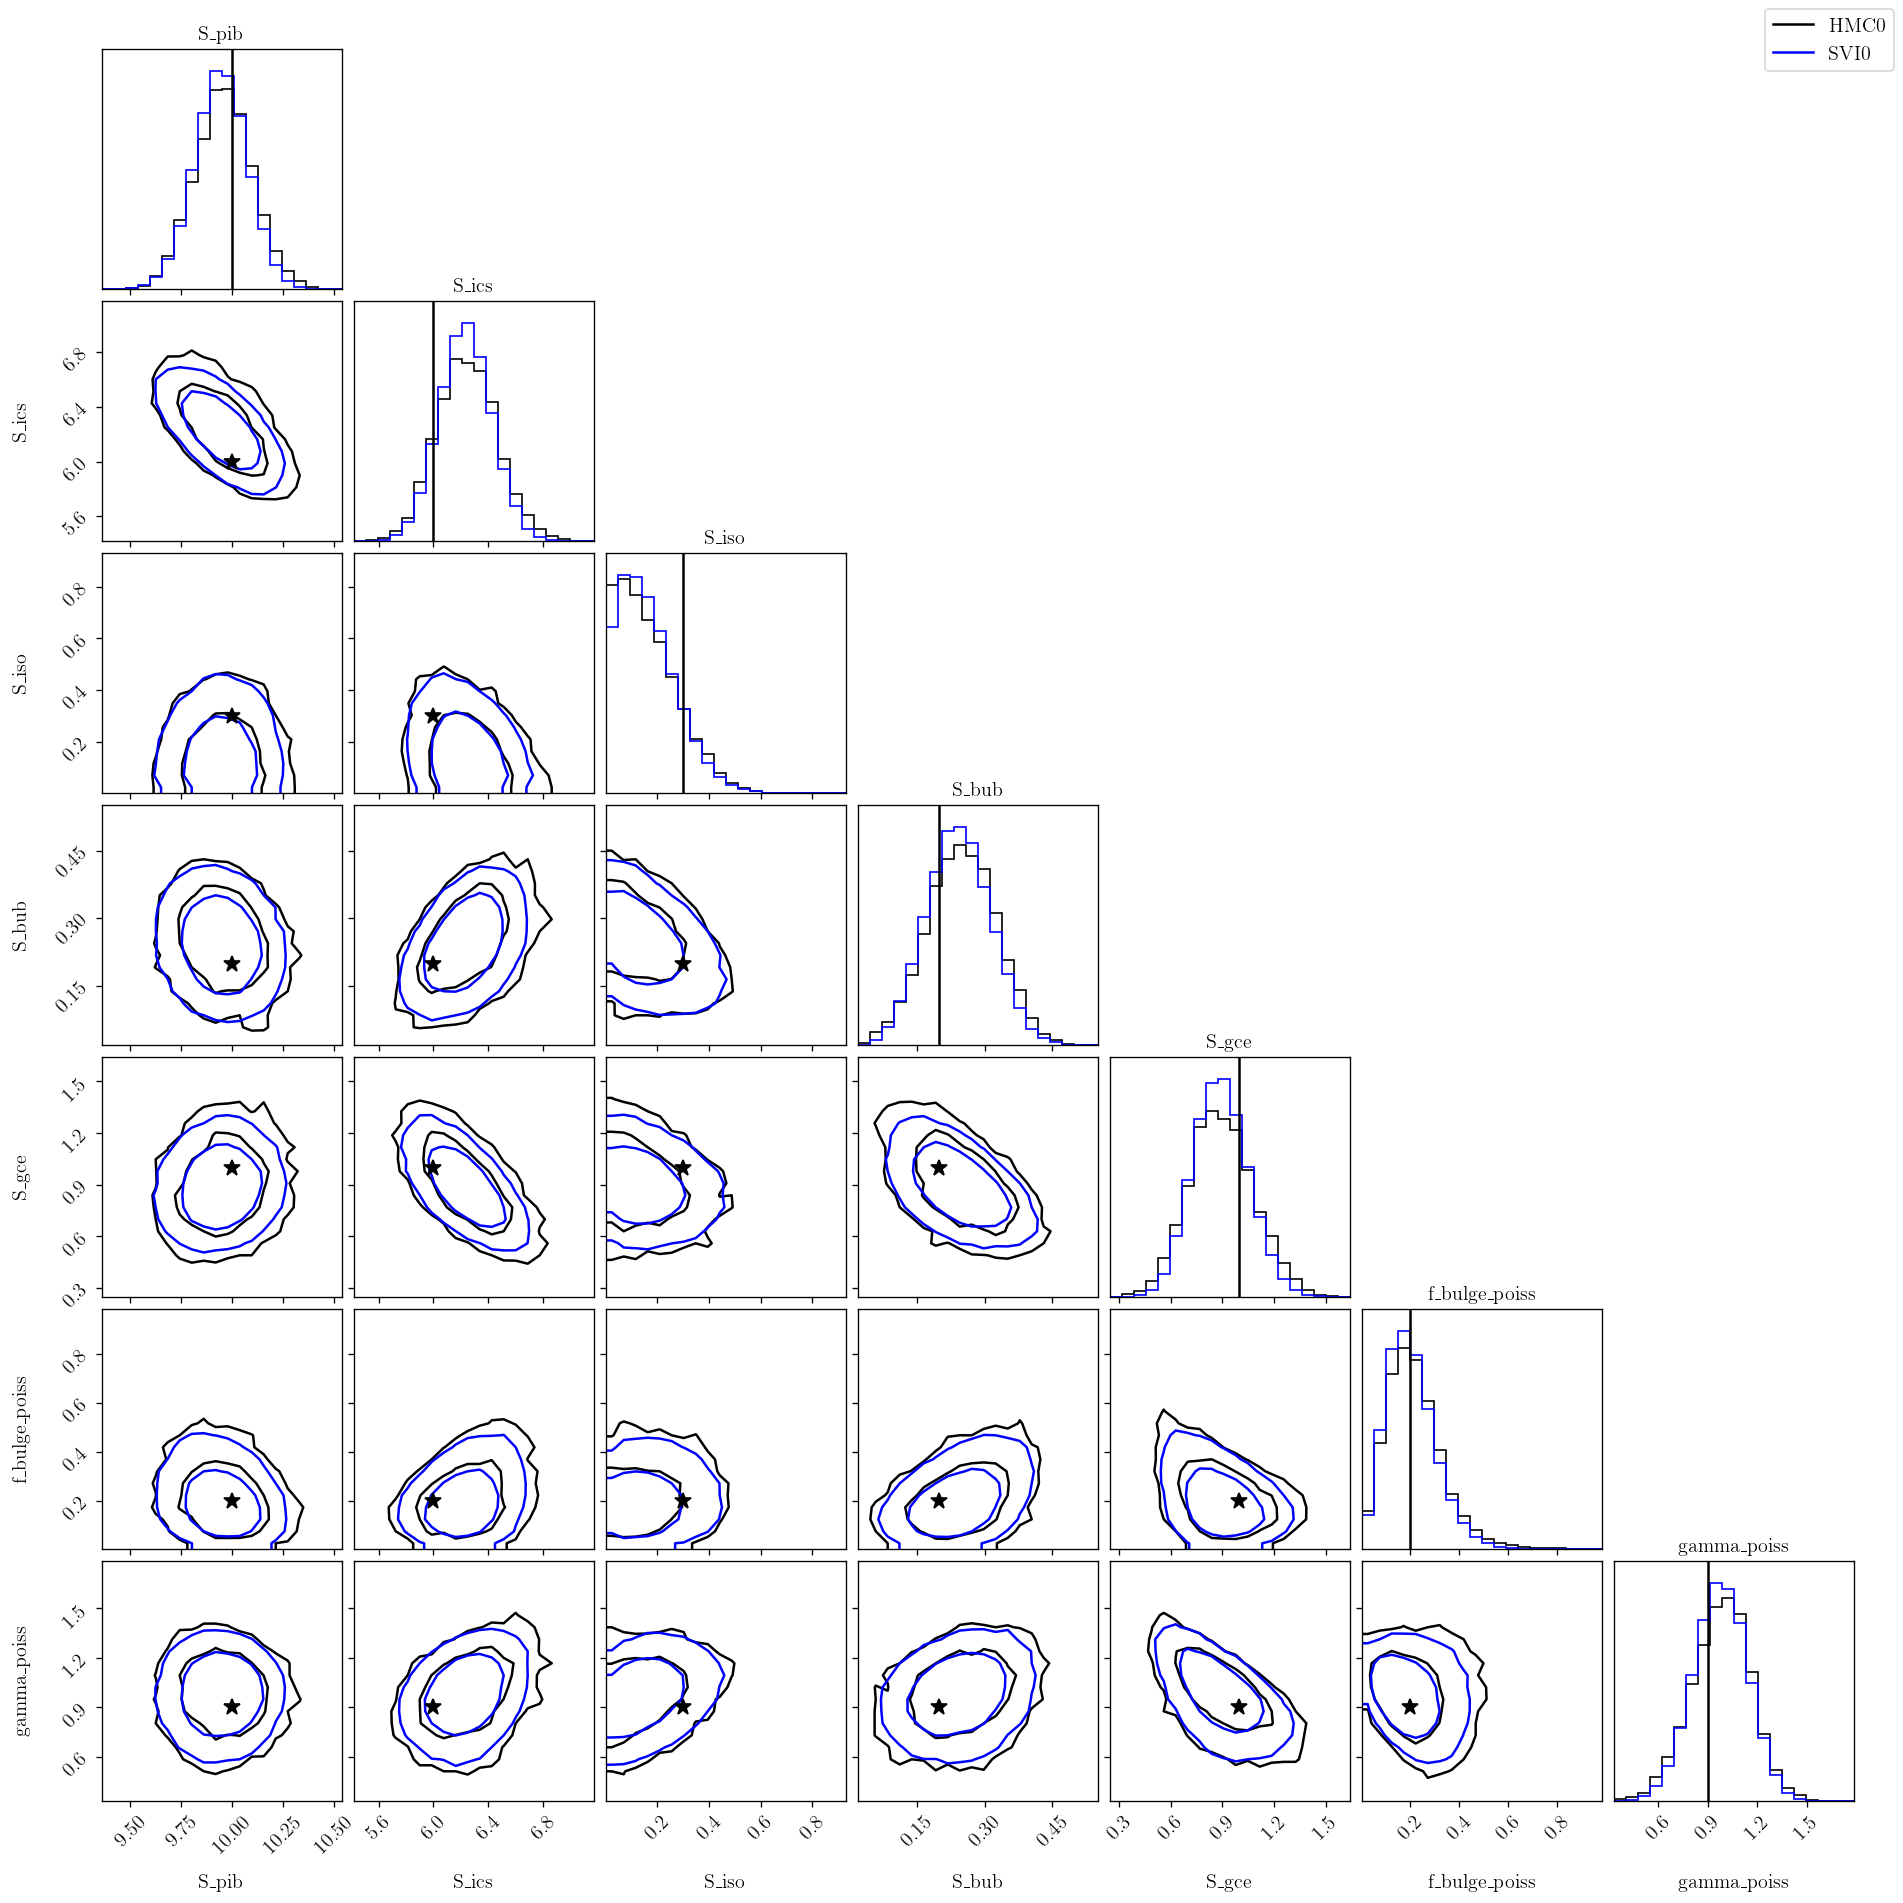

In [7]:
labels = [
    'S_pib', 'S_ics', 'S_iso', 'S_bub', 'S_gce',
    'f_bulge_poiss', 'gamma_poiss'
]
config_dict = {
    'HMC0' : ('../outputs/fit/hmc_Dpois_Mpois/i2_n10000_ns0.p', 'k'),
    'SVI0' : ('../outputs/fit/svi_Dpois_Mpois/i2_n50000_ns10000.p', 'b'),
}
truth_dict = json.load(open('truth_dict_pois230927.json', 'r'))

s_in = {}
labels_dict = {}
colors_dict = {}
for key, (path, color) in config_dict.items():
    s = pickle.load(open(path, 'rb'))
    s_in[key] = {k: s[k] for k in labels}
    labels_dict[key] = key
    colors_dict[key] = color

t_in = {k: truth_dict[k] for k in labels}

multi_corner(s_in, labels, point_est=t_in, colors_dict=colors_dict, labels_dict=labels_dict, save_fn='plots/hmc-svi-pois-post.pdf')

# coverage

In [ ]:
run_name = 'hmc_D23new_Mbase23fix'
# run_name = 'svi_D23new_Mbase23fix'
# run_name = 'hmc_D23new_deltapsf_Mbase23fix_deltapsf'
# run_name = 'svi_D23new_deltapsf_Mbase23fix_deltapsf'
z = pickle.load(open(f'../outputs/fit/{run_name}/p_nominal_actual_dict.p', 'rb'))
print(z.keys())

labels = [
    'S_pib', 'S_ics', 'S_iso', 'S_bub', 'S_gce',
    'Sps_dsk', 'Sps_gce',
    'f_bulge_poiss', 'f_bulge_ps', 'gamma_poiss', 'gamma_ps', 'C', 'zs'
]

probs = [z[k] for k in labels]
ls_s = ['-'] * 10 + [':'] * 10

fig, ax = plt.subplots()

ax.fill_between([0,1], [0,1], color='lightgray')
if labels is None:
    labels = [None for _ in probs]
for prob, label, ls in zip(probs, labels, ls_s):
    ax.plot(prob[0], prob[1], label=label, ls=ls)

n_run = len(probs[0][0])
invcdf_lower, invcdf_upper = roc_finite_sample_band(n_run)
ax.plot(invcdf_upper, np.linspace(0, 1, n_run), 'k:', label=f'{n_run} sample 95\% \ncontainment')
ax.plot(invcdf_lower, np.linspace(0, 1, n_run), 'k:')

ax.set(aspect=1, xlim=(0, 1), ylim=(0, 1))
ax.set(xlabel='Nominal coverage', ylabel='Actual coverage', title=run_name)

fig.legend(bbox_to_anchor=(1, 1), loc='upper left', bbox_transform=ax.transAxes)
plt.tight_layout()
plt.savefig(f'{run_name}.pdf')